# Imports

In [1]:
%pip install kagglehub==0.3.13

  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 1.0.1
    Uninstalling kagglehub-1.0.1:
      Successfully uninstalled kagglehub-1.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip show kagglehub kagglesdk

Name: kagglehub
Version: 0.3.13
Summary: Access Kaggle resources anywhere
Home-page: https://github.com/Kaggle/kagglehub
Author: 
Author-email: Kaggle <support@kaggle.com>
License: Apache License
                                   Version 2.0, January 2004
                                http://www.apache.org/licenses/
        
           TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION
        
           1. Definitions.
        
              "License" shall mean the terms and conditions for use, reproduction,
              and distribution as defined by Sections 1 through 9 of this document.
        
              "Licensor" shall mean the copyright owner or entity authorized by
              the copyright owner that is granting the License.
        
              "Legal Entity" shall mean the union of the acting entity and all
              other entities that control, are controlled by, or are under common
              control with that entity. For the purposes of thi

In [3]:
import numpy as np
print(np.__version__)
print(np.__file__)

2.2.6
c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\numpy\__init__.py


In [4]:
import numpy as np
print(np.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import kagglehub
import nibabel as nib
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

2.2.6


c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Download Dataset

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)

print("Dataset path:", path)

Dataset path: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1


In [6]:
# CHECK DATASET FOLDERS

os.listdir(path)

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']

# Finding all MRI cases

In [7]:
base_path = os.path.join(
    path,
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

cases = []

for folder in os.listdir(base_path):

    full_path = os.path.join(base_path, folder)

    if os.path.isdir(full_path):
        cases.append(full_path)

print("Total cases:", len(cases))
print(cases[:3])

Total cases: 369
['C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_001', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_002', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_003']


In [8]:
# Loads one MRI scan

sample_case = cases[0]

files = os.listdir(sample_case)
print(files)

['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']


In [9]:
# Loading MRI and Mask

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(sample_case, file)

    if "seg" in file.lower():
        mask_path = os.path.join(sample_case, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

FLAIR: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_flair.nii
MASK: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_seg.nii


In [10]:
# getting structure of data

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

    # stoppinh after a few folders
    if "BraTS20_Training_001" in root:
        break

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
-------

In [11]:
# CELL 9 FIND MRI + MASK FILES

patient_folder = None

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)

    if os.path.isdir(full_path):
        patient_folder = full_path
        break

print("Patient folder:", patient_folder)

files = os.listdir(patient_folder)

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(patient_folder, file)

    if "seg" in file.lower():
        mask_path = os.path.join(patient_folder, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

Patient folder: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
FLAIR: None
MASK: None


In [12]:
base_path = os.path.join(path, "BraTS2020_TrainingData")
print(base_path)
print(os.listdir(base_path)[:5])

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
['MICCAI_BraTS2020_TrainingData']


In [13]:
# Getting MRI shape and Mask shape

base_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

patient_folder = next(
    os.path.join(base_path, f)
    for f in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, f))
)

files = os.listdir(patient_folder)

flair_path = next(os.path.join(patient_folder, f) for f in files if "flair" in f.lower())
mask_path  = next(os.path.join(patient_folder, f) for f in files if "seg" in f.lower())

flair = nib.load(flair_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print("MRI shape:", flair.shape)
print("Mask shape:", mask.shape)

MRI shape: (240, 240, 155)
Mask shape: (240, 240, 155)


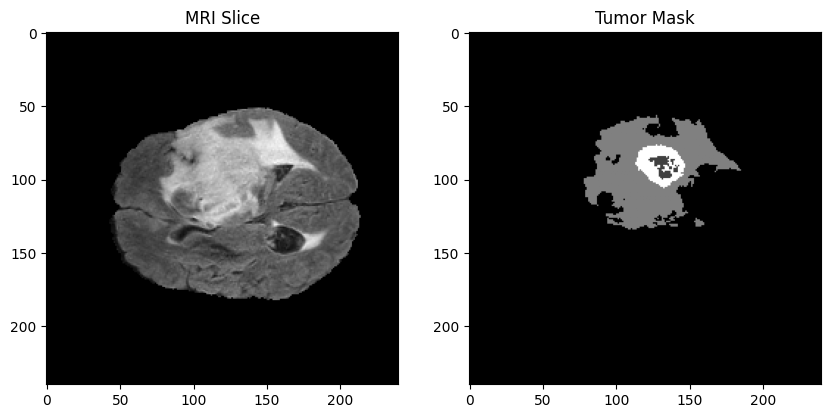

In [14]:
# Show MRI slice and tumor mask
slice_index = 75

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:,:,slice_index], cmap='gray')
plt.title("MRI Slice")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,slice_index], cmap='gray')
plt.title("Tumor Mask")

plt.show()

In [15]:
# CREATE OUTPUT FOLDERS

BASE_DIR = "brain_tumor_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [16]:
# Convert MASK to POLYGON ( for Yolo v8 segmentation model to work)
import cv2
import numpy as np

def mask_to_polygon(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 20:   # slightly stricter
        return None

    return largest.reshape(-1, 2)

In [17]:
image_paths = []
counter = 0

for case in tqdm(cases):

    files = os.listdir(case)

    flair_path = None
    mask_path = None

    for file in files:
        if "flair" in file.lower():
            flair_path = os.path.join(case, file)
        if "seg" in file.lower():
            mask_path = os.path.join(case, file)

    if flair_path is None or mask_path is None:
        continue

    flair = nib.load(flair_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(35, 115, 8):

        image_slice = flair[:, :, i]
        mask_slice = mask[:, :, i]

        is_tumor = np.max(mask_slice) > 0

        if not is_tumor and np.random.rand() > 0.10:
            continue

        polygon = mask_to_polygon(mask_slice)

        if polygon is None or len(polygon) < 4:
            continue

        # converting to correct OpenCV shape before approxPolyDP
        polygon = polygon.reshape(-1, 1, 2).astype(np.int32)

        polygon = cv2.approxPolyDP(
            polygon,
            epsilon=1.5,
            closed=True
        )

        if polygon is None or len(polygon) < 3:
            continue

        # reshaping after approximation
        polygon = polygon.reshape(-1, 2)

        h, w = image_slice.shape

        polygon = polygon.astype(np.float32)

        polygon[:, 0] /= w
        polygon[:, 1] /= h

        flat = polygon.flatten()

        if len(flat) < 6:
            continue

        image_slice = cv2.normalize(image_slice, None, 0, 255, cv2.NORM_MINMAX)
        image_slice = image_slice.astype(np.uint8)

        image_slice = cv2.cvtColor(image_slice, cv2.COLOR_GRAY2RGB)

        filename = f"tumor_{counter}"

        cv2.imwrite(f"{BASE_DIR}/images/train/{filename}.jpg", image_slice)

        with open(f"{BASE_DIR}/labels/train/{filename}.txt", "w") as f:
            f.write("0 " + " ".join(map(str, flat)))

        image_paths.append(filename)
        counter += 1

print("Total saved images:", counter)

100%|██████████| 369/369 [01:08<00:00,  5.39it/s]

Total saved images: 2458


In [18]:
# splitting training and validation sets

train_files, val_files = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))

Train: 1966
Validation: 492


In [19]:
# moving the validation set files
import shutil

for file in val_files:

    shutil.copy(
        f"{BASE_DIR}/images/train/{file}.jpg",
        f"{BASE_DIR}/images/val/{file}.jpg"
    )

    shutil.copy(
        f"{BASE_DIR}/labels/train/{file}.txt",
        f"{BASE_DIR}/labels/val/{file}.txt"
    )

print("Validation files copied.")

Validation files copied.


In [20]:
# creating yolo dataset yaml file
yaml_text = f"""
path: {BASE_DIR}

train: images/train
val: images/val

names:
  0: tumor
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created.")

dataset.yaml created.


In [21]:
# yolo v8 nano segmentation model
model = YOLO("yolov8n-seg.pt")

In [22]:
# best speed/accuracy tradeoff found after tuning and trialing multiple values
model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=192, 
    batch=8,
    workers=2,
    mosaic=0,
    fliplr=0.1,
    scale=0.1,
    degrees=0,
    patience=3,
    cache=True
)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.1, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, perspective=0.0,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002169CD48F70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [23]:
# valiadate the model
metrics = model.val()
print(metrics)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 130.272.2 MB/s, size: 8.3 KB)
val: Scanning C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\labels\val.cache... 492 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 492/492  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.1it/s 6.1s0.2s
                   all        492        492      0.897       0.85      0.904      0.677      0.923      0.837      0.913      0.642
Speed: 0.1ms preprocess, 8.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\runs\segment\val
ultralytics.utils.metrics.SegmentMetrics ob

In [24]:
# test predictions
results = model.predict(
    source=f"{BASE_DIR}/images/val",
    save=True,
    conf=0.25
)


image 1/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_100.jpg: 192x192 1 tumor, 30.9ms
image 2/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1004.jpg: 192x192 1 tumor, 14.7ms
image 3/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1014.jpg: 192x192 1 tumor, 14.8ms
image 4/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1018.jpg: 192x192 (no detections), 15.9ms
image 5/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1023.jpg: 192x192 1 tumor, 15.4ms
image 6/492 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_1027.jpg: 192x192 (no detections), 10.4ms
image 7/492 c:\Use

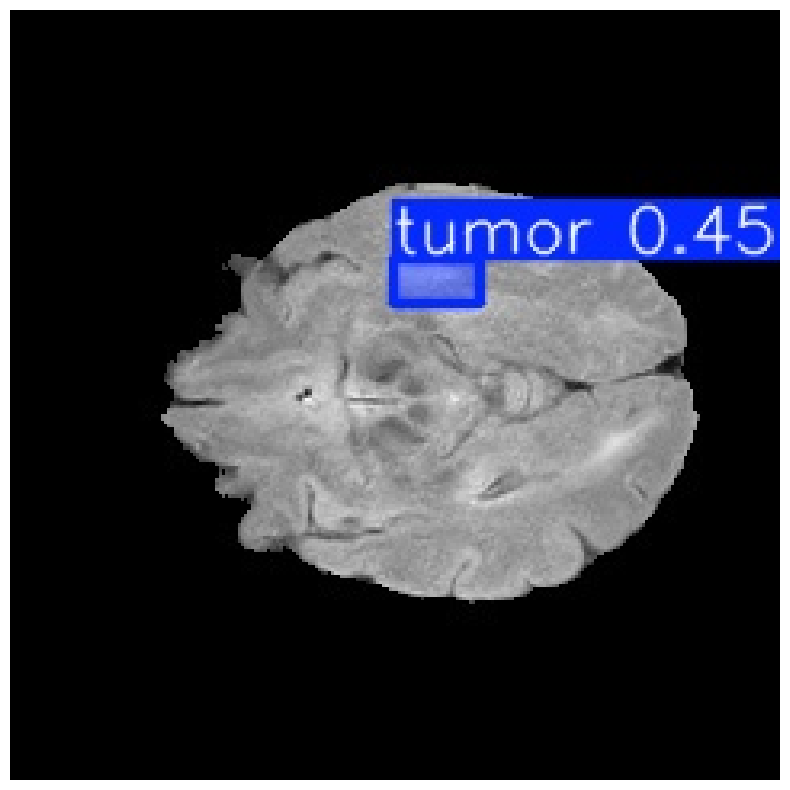

In [25]:
# displaying predictions
prediction_folder = "runs/segment/predict"

predicted_images = os.listdir(prediction_folder)

img = cv2.imread(
    os.path.join(prediction_folder, predicted_images[0])
)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [27]:
# metric scores
metrics = model.val()

print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
val: Fast image access  (ping: 0.00.0 ms, read: 170.231.3 MB/s, size: 9.3 KB)
val: Scanning C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\labels\val.cache... 492 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 492/492 901.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 6.3it/s 4.9s0.1s
                   all        492        492      0.897       0.85      0.904      0.677      0.923      0.837      0.913      0.642
Speed: 0.1ms preprocess, 6.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\runs\segment\val-3
mAP@0.5: 0.9040995459010602
mAP@0.5:0.95: 0.6767234104792494
Precision: 0.8970131982295348
Recall: 0.8497546673910834


# Interpretability

In [29]:
# loading the best model
from ultralytics import YOLO

model = YOLO("runs/segment/train/weights/best.pt")

Images found: 492
Loading: brain_tumor_dataset/images/val\tumor_100.jpg


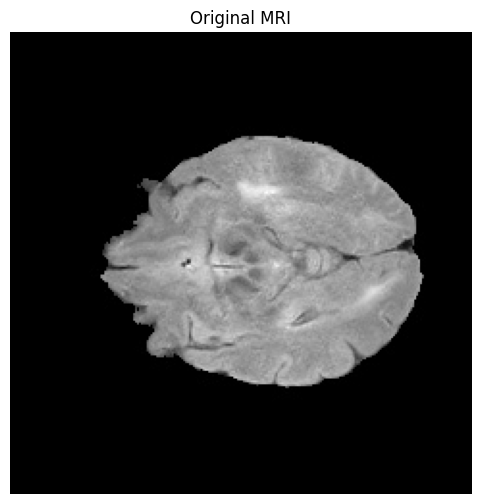

In [30]:
# LOAD IMAGE

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

val_folder = "brain_tumor_dataset/images/val"

# get image list
image_files = [
    f for f in os.listdir(val_folder)
    if f.endswith(".jpg")
]

print("Images found:", len(image_files))

# pick first image
image_name = image_files[0]

image_path = os.path.join(val_folder, image_name)

print("Loading:", image_path)

# read image
img = cv2.imread(image_path)

# safety check
if img is None:
    raise ValueError(f"Failed to load image: {image_path}")

# convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# normalize
img_float = img_rgb.astype(np.float32) / 255.0

# display
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original MRI")
plt.axis("off")
plt.show()

In [31]:
# Yolo prediction
results = model.predict(
    image_path,
    conf=0.25
)

result = results[0]

print(result)


image 1/1 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\brain_tumor_dataset\images\val\tumor_100.jpg: 192x192 1 tumor, 40.2ms
Speed: 30.4ms preprocess, 40.2ms inference, 3.2ms postprocess per image at shape (1, 3, 192, 192)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'tumor'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

    

In [32]:
print(result.speed)

{'preprocess': 30.375100090168417, 'inference': 40.22829991299659, 'postprocess': 3.2476000487804413}
